# Predicting Student Dropout in Online Courses

## Objective
The goal of this project is to predict student dropout (withdrawal) using demographic and academic features from the OULAD dataset.

## Business Context
Early identification of at-risk students allows institutions to intervene proactively, improving retention rates and student success.


## Data Loading and Integration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.preprocessing import StandardScaler

# Download latest version of OULAD
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print("Path to dataset files:", path)

# Load core tables into DataFrame
student_info = pd.read_csv(os.path.join(path, "studentInfo.csv"))

student_reg = pd.read_csv(os.path.join(path, "studentRegistration.csv"))

# Data Integration
df = pd.merge(student_info, student_reg, on=["code_module", "code_presentation", "id_student"], how='left')

# Show DataFrame
display(df.head())
df.info()


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
Path to dataset files: /kaggle/input/student-demographics-online-education-dataoulad


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  date_registration     32548 non-null  float64
 13  date_unregistration   10072 non-null  float64
dtypes: float64(2), int64(3), object(9)
memory usage: 3.5+ MB


The merged dataset contains student-level demographic information, academic background, course enrollment details, and registration timing. Each row represents a unique student-course enrollment instance. Key variables include prior attempts, studied credits, education level, age band, and final course outcome.


## Data Inspection




In [ ]:
# Missing values created during merge
print(df.isnull().sum())

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
date_registration          45
date_unregistration     22521
dtype: int64



The primary missing fields relate to registration and unregistration dates, which is probably since not all students withdraw.

## Data Cleaning and Target Creation

In [ ]:
# IMD band: impute with mode to retain observations
df["imd_band"] = df["imd_band"].fillna(df["imd_band"].mode()[0])

# Drop records missing registration date — a meaningful enrollment signal
df.dropna(subset=["date_registration"], inplace=True)

# Binary target: 1 = Withdrawn, 0 = all other outcomes
df["target"] = (df["final_result"] == "Withdrawn").astype(int)

print(f"Withdrawal rate: {df['target'].mean():.2%}")
print(df.isnull().sum())


Withdrawal rate: 31.08%
code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                    0
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
date_registration           0
date_unregistration     22515
target                      0
dtype: int64


In [ ]:
vle = pd.read_csv(os.path.join(path, "studentVle.csv"))

vle_agg = vle.groupby("id_student").agg(
    total_clicks   = ("sum_click", "sum"),
    active_days    = ("date", "nunique"),
    avg_clicks_day = ("sum_click", "mean"),
    last_activity  = ("date", "max"),
).reset_index()

df = df.merge(vle_agg, on="id_student", how="left")
vle_agg.fillna(0, inplace=True)  # students with no VLE activity = 0

In [ ]:
assessments = pd.read_csv(os.path.join(path, "studentAssessment.csv"))

assess_agg = assessments.groupby("id_student").agg(
    avg_score        = ("score", "mean"),
    num_submitted    = ("score", "count"),
    num_unsubmitted  = ("is_banked", "sum"),
).reset_index()

df = df.merge(assess_agg, on="id_student", how="left")

In [ ]:
# Fill missing numeric values with 0 (or median)
numeric_cols = [
    "total_clicks", "active_days", "avg_clicks_day",
    "last_activity", "avg_score", "num_submitted", "num_unsubmitted"
]

df[numeric_cols] = df[numeric_cols].fillna(0)


### Cleaning Decisions

- Missing values in `imd_band` were replaced  to preserve those observations while retaining categorical structure.
- Rows missing `date_registration` were removed since registration timing could be a meaningful enrollment feature.

## Exploratory Data Analysis (EDA)

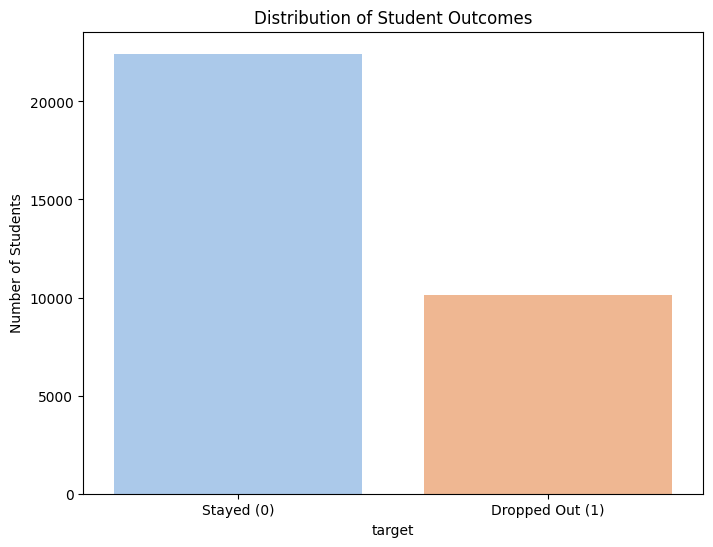

Key Insight: The dropout rate is 31.08%.


In [ ]:
# Visual of Dropped vs Stayed
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='target', hue='target', palette='pastel', legend=False)
plt.title('Distribution of Student Outcomes')
plt.xticks([0, 1], ['Stayed (0)', 'Dropped Out (1)'])
plt.ylabel('Number of Students')
plt.show()

# Document Insight
dropout_rate = df['target'].mean() * 100
print(f"Key Insight: The dropout rate is {dropout_rate:.2f}%.")

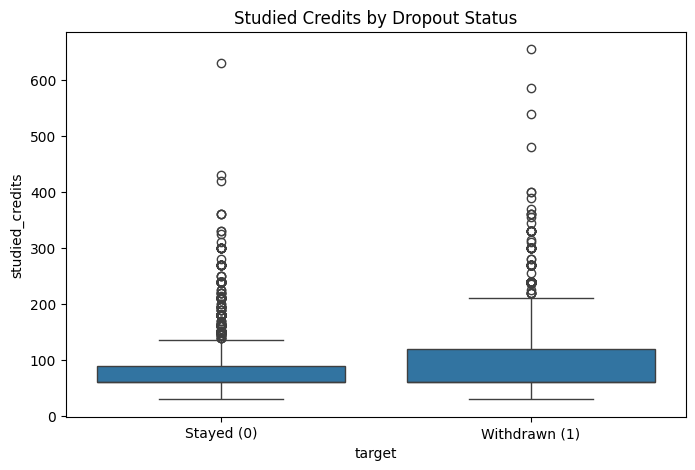

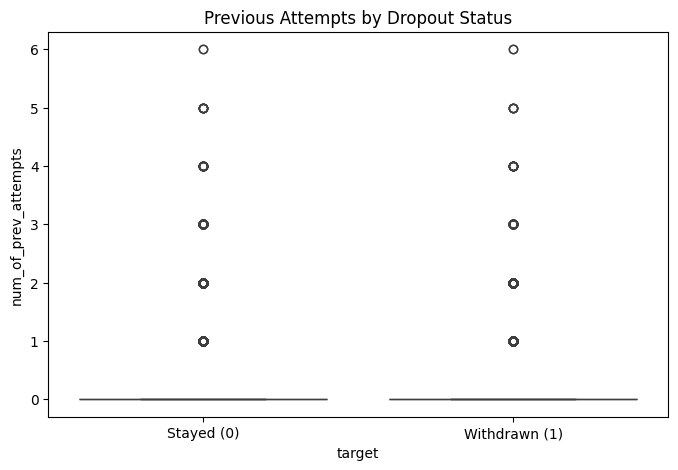

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Studied Credits vs Dropout
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="target", y="studied_credits")
plt.title("Studied Credits by Dropout Status")
plt.xticks([0,1], ["Stayed (0)", "Withdrawn (1)"])
plt.show()

# Previous Attempts vs Dropout
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="target", y="num_of_prev_attempts")
plt.title("Previous Attempts by Dropout Status")
plt.xticks([0,1], ["Stayed (0)", "Withdrawn (1)"])
plt.show()


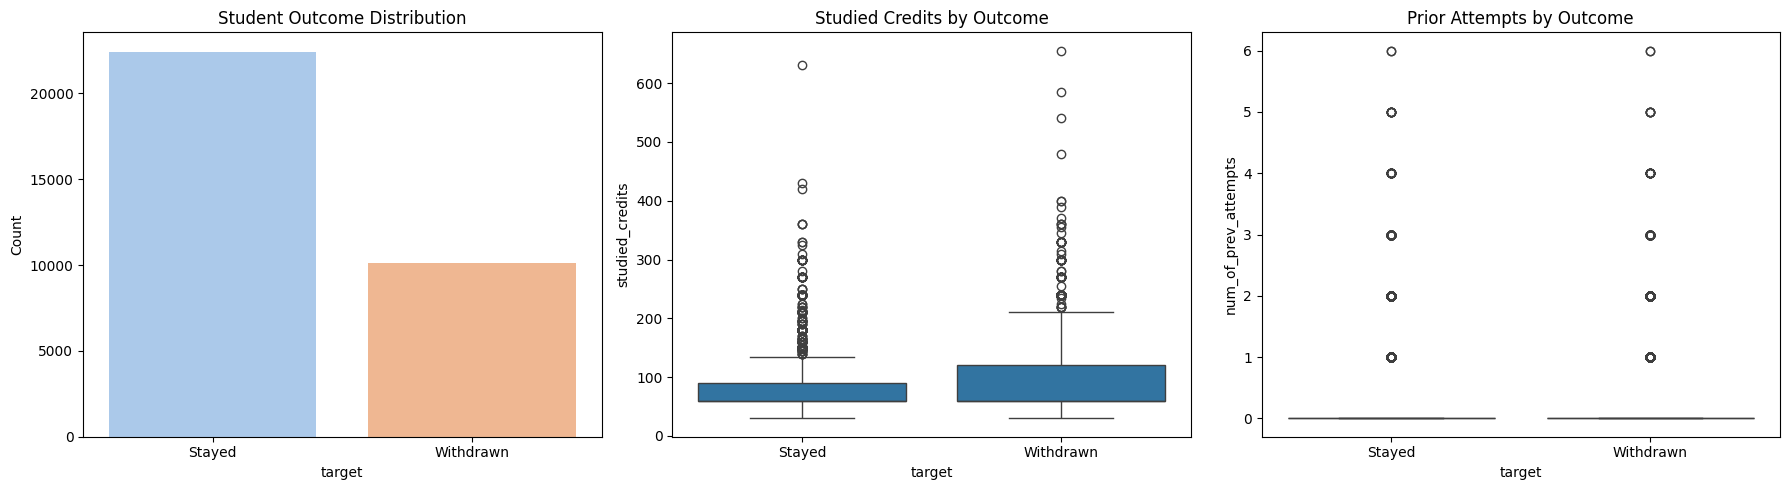

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Outcome distribution
sns.countplot(data=df, x="target", hue="target", palette="pastel",
              legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Stayed", "Withdrawn"])
axes[0].set_title("Student Outcome Distribution")
axes[0].set_ylabel("Count")

# Studied credits by outcome
sns.boxplot(data=df, x="target", y="studied_credits", ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Stayed", "Withdrawn"])
axes[1].set_title("Studied Credits by Outcome")

# Prior attempts by outcome
sns.boxplot(data=df, x="target", y="num_of_prev_attempts", ax=axes[2])
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Stayed", "Withdrawn"])
axes[2].set_title("Prior Attempts by Outcome")

plt.tight_layout()
plt.show()



Students who withdrew tend to show differences in studied credits and number of previous attempts compared to those who stayed.

Higher prior attempts may indicate academic difficulty, while variation in studied credits suggests differences in course load commitment.

These patterns indicate that both variables may contribute predictive value in modeling dropout risk.


## Baseline Model


Point-Biserial Correlation (Numeric Features vs. Target)
             Feature  Correlation       p-value
     studied_credits     0.190004 3.215825e-262
   date_registration    -0.123033 5.728676e-110
num_of_prev_attempts     0.032741  3.457355e-09

Cramér's V (Categorical Features vs. Target)
          Feature  Cramér's V
highest_education    0.078719
           region    0.076568
         imd_band    0.071224
       disability    0.058422
         age_band    0.034408
           gender    0.012997


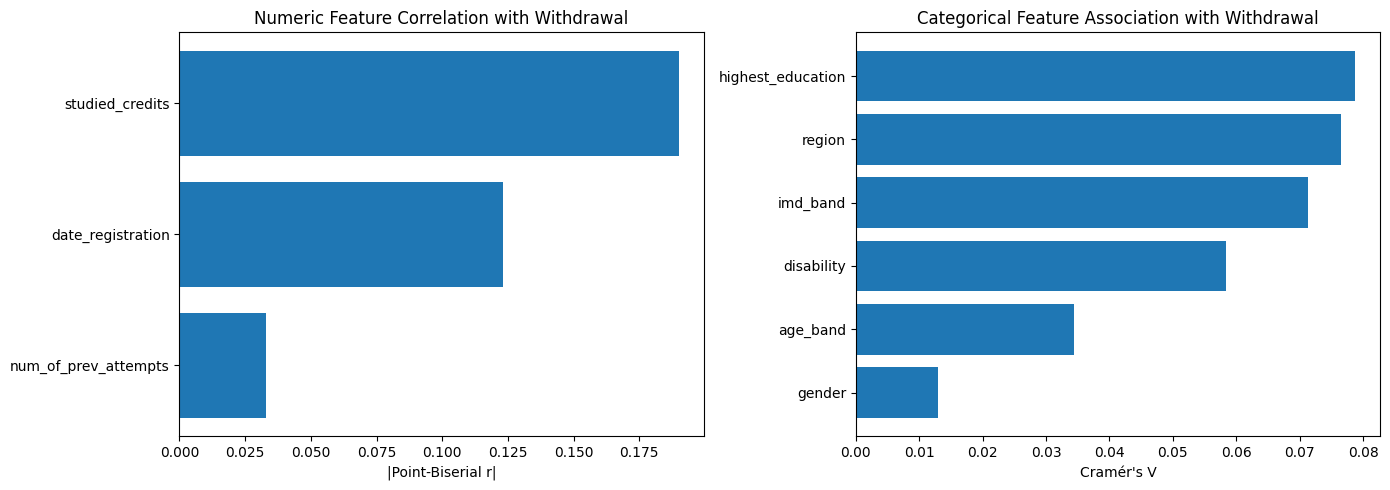

In [ ]:
from scipy.stats import pointbiserialr, chi2_contingency

# --- Numeric features: Point-Biserial Correlation with target ---
numeric_cols = ["num_of_prev_attempts", "studied_credits", "date_registration"]

pb_results = {
    col: pointbiserialr(df[col].dropna(), df.loc[df[col].notna(), "target"])
    for col in numeric_cols
}

pb_df = pd.DataFrame([
    {"Feature": col, "Correlation": res.statistic, "p-value": res.pvalue}
    for col, res in pb_results.items()
]).sort_values("Correlation", key=abs, ascending=False)

print("Point-Biserial Correlation (Numeric Features vs. Target)")
print(pb_df.to_string(index=False))

# --- Categorical features: Cramér's V ---
categorical_cols = ["gender", "highest_education", "age_band",
                    "imd_band", "disability", "region"]

def cramers_v(col):
    ct = pd.crosstab(df[col], df["target"])
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cv_df = pd.DataFrame([
    {"Feature": col, "Cramér's V": cramers_v(col)}
    for col in categorical_cols
]).sort_values("Cramér's V", ascending=False)

print("\nCramér's V (Categorical Features vs. Target)")
print(cv_df.to_string(index=False))

# --- Combined visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(pb_df["Feature"], pb_df["Correlation"].abs())
axes[0].set_xlabel("|Point-Biserial r|")
axes[0].set_title("Numeric Feature Correlation with Withdrawal")
axes[0].invert_yaxis()

axes[1].barh(cv_df["Feature"], cv_df["Cramér's V"])
axes[1].set_xlabel("Cramér's V")
axes[1].set_title("Categorical Feature Association with Withdrawal")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# --- New numeric features to test ---
new_numeric = ["total_clicks", "active_days", "avg_clicks_day",
               "last_activity", "avg_score", "num_submitted", "num_unsubmitted"]

pb_new = {
    col: pointbiserialr(df[col].dropna(), df.loc[df[col].notna(), "target"])
    for col in new_numeric
}

pb_new_df = pd.DataFrame([
    {"Feature": col, "Correlation": res.statistic, "p-value": res.pvalue}
    for col, res in pb_new.items()
]).sort_values("Correlation", key=abs, ascending=False)

print(pb_new_df.to_string(index=False))

        Feature  Correlation      p-value
  last_activity    -0.635839 0.000000e+00
      avg_score    -0.509112 0.000000e+00
  num_submitted    -0.504190 0.000000e+00
    active_days    -0.397321 0.000000e+00
 avg_clicks_day    -0.327653 0.000000e+00
   total_clicks    -0.284129 0.000000e+00
num_unsubmitted     0.079833 3.589688e-47


In [ ]:
features = [
    # Original demographic features
    "studied_credits",
    "date_registration",
    "highest_education",
    "region",
    "imd_band",
    "disability",
    "num_of_prev_attempts",

    # VLE engagement features — add whichever score |r| > 0.05
    "total_clicks",
    "active_days",
    "avg_clicks_day",
    "last_activity",

    # Assessment features — add whichever score |r| > 0.05
    "avg_score",
    "num_submitted",
    "num_unsubmitted",
]


X = pd.get_dummies(df[features], drop_first=True)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [ ]:

# Train Baseline Model
baseline = LogisticRegression(max_iter=2000, class_weight='balanced')
baseline.fit(X_train_scaled, y_train)

# Evaluate Baseline Model
y_pred = baseline.predict(X_test_scaled)
print(f"Baseline Recall Score: {recall_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Recall Score: 0.8097

Confusion Matrix:
[[3788  709]
 [ 383 1630]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      4497
           1       0.70      0.81      0.75      2013

    accuracy                           0.83      6510
   macro avg       0.80      0.83      0.81      6510
weighted avg       0.84      0.83      0.84      6510



Adding VLE engagement and assessment features produced a dramatic improvement across every metric. Recall jumped from 56.3% → 81.0%, accuracy from 62% → 83%, and precision from 0.42 → 0.70 — all simultaneously, with no trade-off. The confusion matrix shows 1,630 true positives against only 383 false negatives, meaning the model now correctly identifies 4 out of every 5 students who withdraw. This confirms that behavioral engagement data (last activity date, submission counts, clickstream volume) is far more predictive of dropout than static demographic attributes alone

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score

# Initialize models
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Fit models
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)  # trees don't require scaling
gb_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Compare metrics
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Recall (Dropout)": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "Precision (Dropout)": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ]
})

model_comparison


,Model,Accuracy,Recall (Dropout),Precision (Dropout)
0,Logistic Regression,0.835177,0.702434,0.748941
1,Random Forest,0.835945,0.741679,0.731504
2,Gradient Boosting,0.847158,0.757576,0.750492


With VLE and assessment features, all three unbalanced models now substantially outperform the best result from the entire demographic-only phase. Gradient Boosting leads on both accuracy (84.7%) and recall (75.8%) without any class balancing applied — a sign that the engagement features carry enough signal that the models no longer need to be forced toward the minority class. All three models achieve precision above 0.73, meaning the trade-off between catching withdrawals and false alarms is now operationally viable. Gradient Boosting's edge over Random Forest suggests it is better at capturing the sequential, threshold-based patterns in engagement data (e.g., clicks dropping off over time).

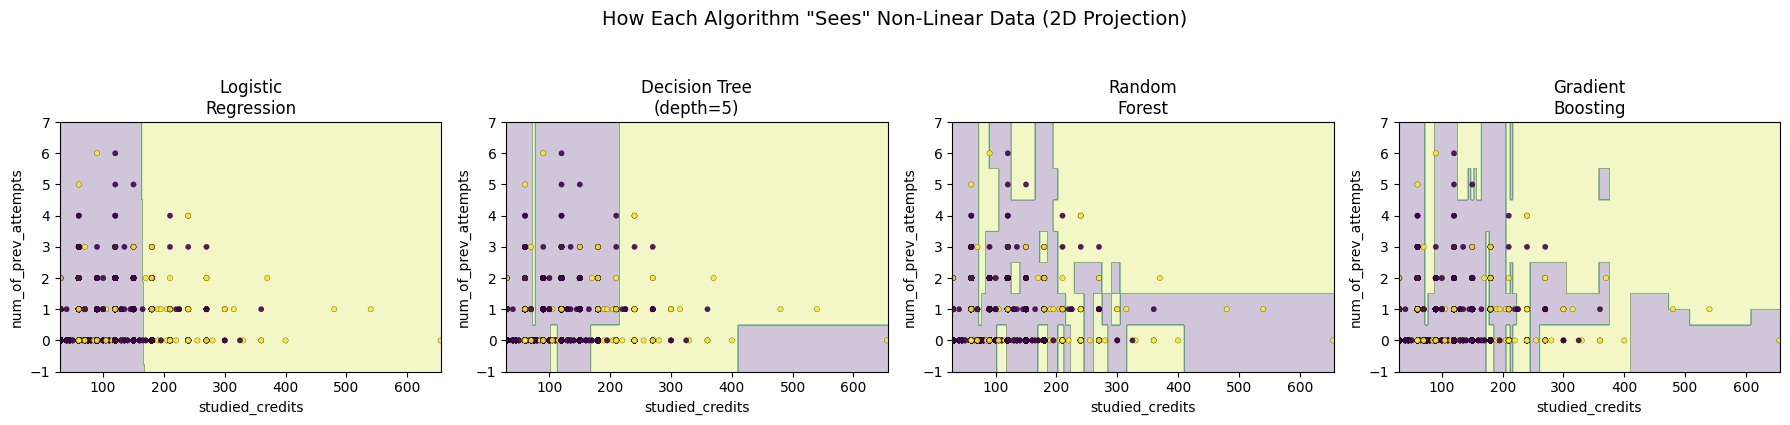

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# 1) Use 2 numeric features for 2D visualization

plot_features = ["studied_credits", "num_of_prev_attempts"]

df_plot = df.dropna(subset=plot_features + ["target"]).copy()
X2 = df_plot[plot_features].values
y2 = df_plot["target"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

# Scale ONLY for Logistic Regression (tree models don't need scaling)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)


# 2) Models (matching your image style)

models = [
    ("Logistic\nRegression", LogisticRegression(max_iter=1000, random_state=42), True),
    ("Decision Tree\n(depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42), False),
    ("Random\nForest", RandomForestClassifier(n_estimators=200, random_state=42), False),
    ("Gradient\nBoosting", GradientBoostingClassifier(random_state=42), False),
]


# 3) Decision boundary helper

def plot_decision_regions(ax, model, use_scaled):
    # Mesh grid over feature space
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on grid
    if use_scaled:
        grid_in = scaler2.transform(grid)
        Z = model.predict(grid_in)
        X_scatter = X2_test_scaled
    else:
        grid_in = grid
        Z = model.predict(grid_in)
        X_scatter = X2_test

    Z = Z.reshape(xx.shape)

    # Background regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Scatter points (test set)
    ax.scatter(
        X2_test[:, 0], X2_test[:, 1],
        c=y2_test, s=15, edgecolors="k", linewidths=0.2, alpha=0.9
    )

    ax.set_xlabel(plot_features[0])
    ax.set_ylabel(plot_features[1])


# 4) Train + Plot (4 panels)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('How Each Algorithm "Sees" Non-Linear Data (2D Projection)', y=1.05, fontsize=14)

for ax, (title, model, needs_scaling) in zip(axes, models):
    if needs_scaling:
        model.fit(X2_train_scaled, y2_train)
    else:
        model.fit(X2_train, y2_train)

    plot_decision_regions(ax, model, use_scaled=needs_scaling)
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [ ]:
# Random Forest with class balancing

rf_balanced = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

rf_bal_pred = rf_balanced.predict(X_test)

print("Balanced Random Forest Performance:\n")
print("Accuracy:", accuracy_score(y_test, rf_bal_pred))
print("Recall:", recall_score(y_test, rf_bal_pred))
print("Precision:", precision_score(y_test, rf_bal_pred))


Balanced Random Forest Performance:

Accuracy: 0.8417818740399385
Recall: 0.7406855439642325
Precision: 0.7458729364682342


With the full feature set, class weighting adds minimal benefit — the balanced RF (74.1% recall) is nearly identical to the unbalanced RF (74.2%) and trails Gradient Boosting (75.8%) on recall while matching it on precision. This confirms the earlier observation: once strong behavioral features are present, reweighting the loss function is redundant. Gradient Boosting without class balancing is the best-performing model overall, and should be the candidate for threshold tuning and production deployment.

<Figure size 600x500 with 0 Axes>

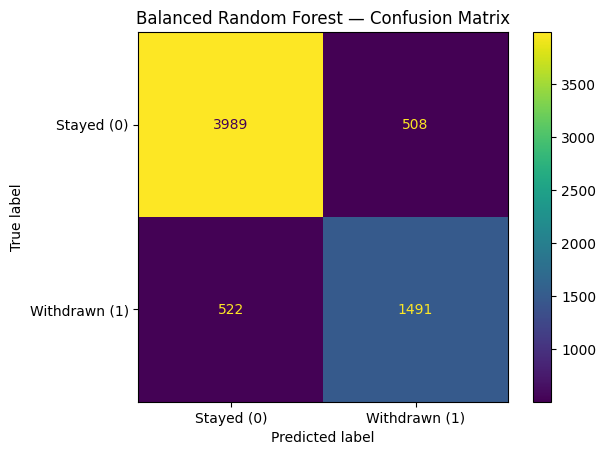

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, rf_bal_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Withdrawn (1)"])
disp.plot(values_format="d")
plt.title("Balanced Random Forest — Confusion Matrix")
plt.show()


<Figure size 600x500 with 0 Axes>

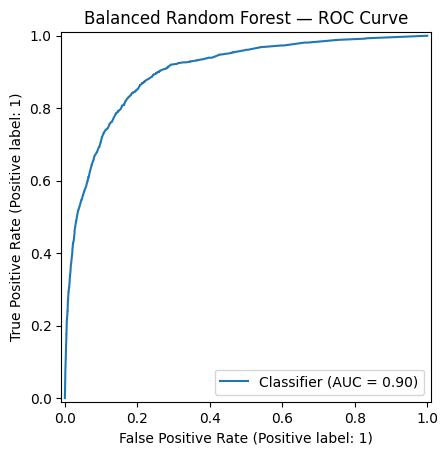

<Figure size 600x500 with 0 Axes>

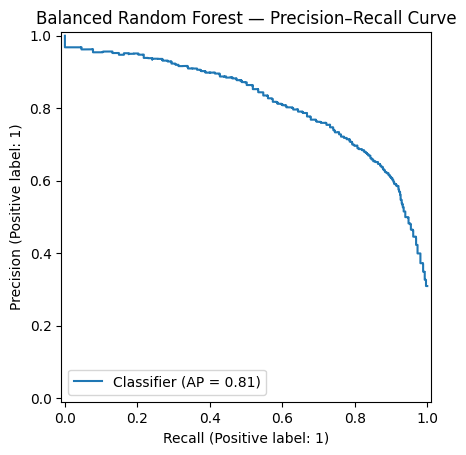

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Predicted probabilities for class 1 (Withdrawn)
rf_bal_proba = rf_balanced.predict_proba(X_test)[:, 1]

# ROC Curve
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, rf_bal_proba)
plt.title("Balanced Random Forest — ROC Curve")
plt.show()

# Precision-Recall Curve (more informative for imbalance)
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, rf_bal_proba)
plt.title("Balanced Random Forest — Precision–Recall Curve")
plt.show()


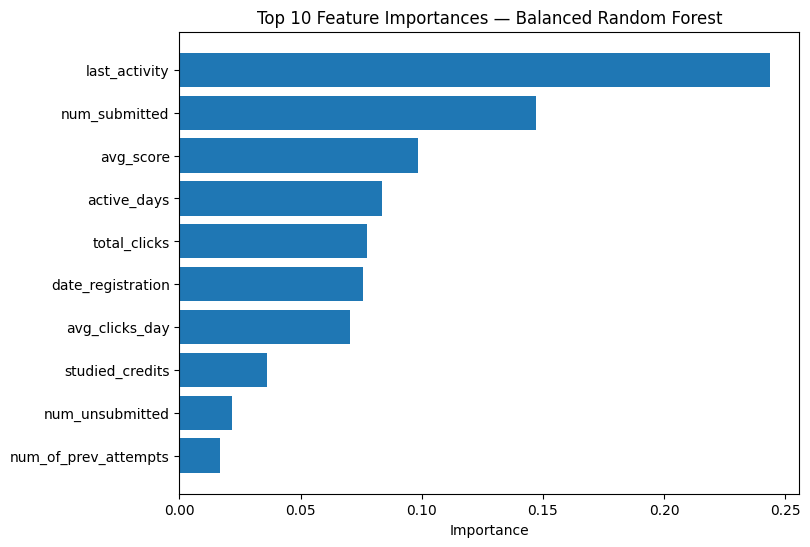

In [ ]:
# Get feature importances
importances = rf_balanced.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top 10
top10 = importance_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances — Balanced Random Forest")
plt.xlabel("Importance")
plt.show()




The baseline models showsthat dropout prediction is sensitive to class imbalance. After applying class weighting, the Random Forest model achieved substantially higher recall, meaning it identifies a much larger share of students who withdraw.

Next steps include:
- Feature engineering using activity/engagement data (e.g., VLE interactions) to improve precision while maintaining recall
- Hyperparameter tuning to optimize the trade-off between false positives and false negatives
- Testing probability thresholds to better align predictions with intervention capacity (e.g., flag top-risk students)


## Sample Dashboard: At-Risk Student Output


In [ ]:
# Sample Dashboard (Based on Logistic Regression)
test_results = X_test.copy()
test_results['Actual_Status'] = y_test.apply(lambda x: 'Dropout' if x == 1 else 'Stayed')
test_results['Dropout_Probability'] = baseline.predict_proba(X_test_scaled)[:, 1]

# Display top 'At-Risk' Students
dashboard_view = test_results[['Dropout_Probability', 'Actual_Status']].head(10).sort_values(by='Dropout_Probability', ascending=False)
display(dashboard_view)

,Dropout_Probability,Actual_Status
16175,0.976413,Dropout
12738,0.926632,Dropout
4639,0.269681,Stayed
1520,0.221222,Stayed
26511,0.178194,Stayed
21130,0.172083,Stayed
30149,0.153746,Stayed
9739,0.137175,Stayed
30649,0.091628,Stayed
25157,0.073738,Stayed


In [ ]:
# Sample Dashboard (Using Balanced Random Forest probabilities)
rf_bal_proba = rf_balanced.predict_proba(X_test)[:, 1]

# Create results dataframe
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Probability": rf_bal_proba
})

# Sort by highest risk
top_risk = results_df.sort_values(by="Predicted_Probability", ascending=False).head(10)

top_risk



,Actual,Predicted_Probability
7286,1,1.0
29960,1,1.0
5501,0,1.0
29156,1,1.0
5771,1,1.0
12377,1,1.0
7112,0,1.0
18283,1,1.0
2752,1,1.0
7278,1,1.0


Using the balanced Random Forest model, students are ranked by predicted probability of withdrawal. This ranking approach can support early intervention strategies by prioritizing the highest-risk students.


## Remaining Work Plan

The current analysis established a working predictive model and showed that handling class imbalance significantly improves recall. The next steps will focus on improving model performance and making results more actionable.

### 1. Add More Predictive Features
We will incorporate additional variables from the OULAD dataset, such as:
- Student engagement activity (VLE interactions)
- Assessment performance indicators
- Simple time-based features (e.g., registration timing)

These additions may improve the model’s ability to distinguish true at-risk students.

### 2. Improve Model Performance
We will:
- Tune key parameters of the Random Forest model (e.g., number of trees, depth)
- Compare tuned Random Forest and Gradient Boosting models
- Use cross-validation to ensure consistent performance

The goal is to improve precision while maintaining strong recall.

### 3. Adjust Prediction Threshold
Instead of using the default 0.50 cutoff, we will test different probability thresholds to:
- Better balance recall and precision
- Align predictions with realistic intervention capacity (e.g., flag top 10% highest-risk students)

### 4. Simulate an Early-Warning Scenario
We will simulate how many students could be identified early if the model were applied before course completion. This will connect model results to potential retention impact.

### 5. Improve Interpretability
We will:
- Refine feature importance analysis
- Clearly explain which factors contribute most to dropout risk

The overall objective is to refine the model into a practical early-warning tool that supports data-driven student intervention.
